# Naive Bayes — Play Store Reviews

En este proyecto voy a clasificar reseñas de Google Play como negativas o positivas usando Naive Bayes.

De momento lo voy a hacer simple y alineado con la teoría: cargar datos, limpiar texto, vectorizar con `CountVectorizer` y comparar `GaussianNB`, `MultinomialNB` y `BernoulliNB`.


In [198]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

plt.style.use("./apple.mplstyle")

SEPARATOR = 120 * "-"

## Paso 1: Carga del conjunto de datos

In [182]:
df = pd.read_csv("../data/raw/playstore_reviews.csv")
display(f"Shape: {df.shape}")
display(SEPARATOR)
display(f"Head del dataframe:")
display(df.head())
display(SEPARATOR)
display(f"Info del dataset:")
display(df.info())

'Shape: (891, 3)'

'------------------------------------------------------------------------------------------------------------------------'

'Head del dataframe:'

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


'------------------------------------------------------------------------------------------------------------------------'

'Info del dataset:'

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB


None

Distribución del target:
  Negativas (0): 584 (65.54%)
  Positivas (1): 307 (34.46%)
------------------------------------------------------------------------------------------------------------------------


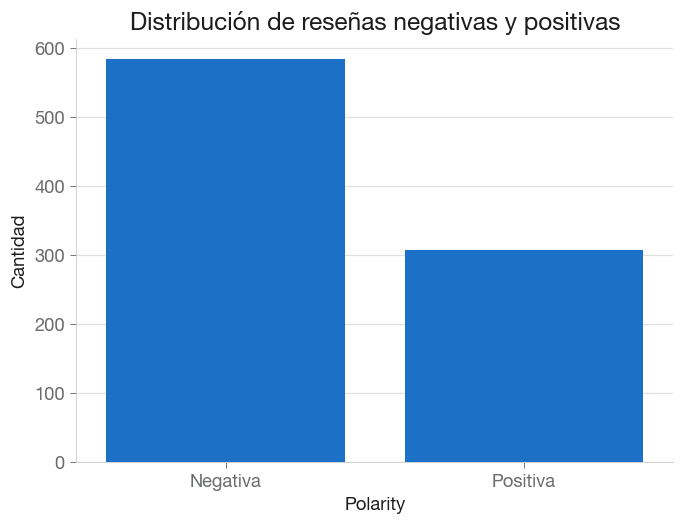

In [183]:
target_counts = df["polarity"].value_counts().sort_index()
target_percent = (target_counts / len(df) * 100).round(2)

print("Distribución del target:")
print(f"  Negativas (0): {target_counts[0]} ({target_percent[0]}%)")
print(f"  Positivas (1): {target_counts[1]} ({target_percent[1]}%)")
print(SEPARATOR)

plt.figure(figsize=(7, 5))
sns.barplot(x=["Negativa", "Positiva"], y=target_counts.values)
plt.title("Distribución de reseñas negativas y positivas")
plt.xlabel("Polarity")
plt.ylabel("Cantidad")
plt.show()

El dataset tiene tres columnas y 891 registros:

- `package_name`: nombre de la aplicación. Esta la vamos a eliminar.
- `review`: texto de la reseña. Hay que procesarla para ver la relación de las palabras con el atributo `polarity`.
- `polarity`: clase objetivo (`0` negativa, `1` positiva).

No hay nulos en el dataset.

La distribución del `target` es de un 65% de valoraciones negativas.

## Paso 2: Procesamiento del texto

Según el enunciado, preparo el texto así:

1. elimino espacios al inicio/final;
2. paso todo a minúsculas;
3. elimino `package_name`;
4. separo `X` e `y`;
5. vectorizo con `CountVectorizer(stop_words="english")`.

### 2.1. Limpiar el texto

In [184]:
df["review"] = df["review"].str.strip().str.lower()

### 2.2. Eliminar `package_name`

In [185]:
df = df.drop("package_name", axis=1, errors='ignore')

In [186]:
display(df.head())
print(SEPARATOR)
print(f"Shape después de limpiar: {df.shape}")

,review,polarity
0,privacy at least put some option appear offlin...,0
1,"messenger issues ever since the last update, i...",0
2,profile any time my wife or anybody has more t...,0
3,the new features suck for those of us who don'...,0
4,forced reload on uploading pic on replying com...,0


------------------------------------------------------------------------------------------------------------------------
Shape después de limpiar: (891, 2)


### 2.3. Separar `X` e `y` y hacer `train/test split`

In [187]:
X = df["review"]
y = df["polarity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2.4. Vectorizar con `CountVectorizer`

In [188]:
vectorizer = CountVectorizer(stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Shape de X_train_vec: {X_train_vec.shape}")
print(f"Shape del X_test_vec: {X_test_vec.shape}")
print(f"Palabras en el vocabulario: {len(vectorizer.get_feature_names_out())}")

Shape de X_train_vec: (712, 3310)
Shape del X_test_vec: (179, 3310)
Palabras en el vocabulario: 3310


## Función simple para evaluar modelos

In [189]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print("+" + "-" * 10 + "-" * len(name) + "+")
    print(f"| Modelo: {name} |")
    print("+" + "-" * 10 + "-" * len(name) + "+")
    print(f"Accuracy: {acc:.4f}")
    print()
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=["Negativa", "Positiva"]))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negativa", "Positiva"],
                yticklabels=["Negativa", "Positiva"])
    plt.title(f"Matriz de confusión — {name}")
    plt.ylabel("Real")
    plt.xlabel("Predicción")
    plt.show()
    print(SEPARATOR)

    return acc

## Paso 3: Construye un Naive Bayes

Como `CountVectorizer` genera conteos de palabras, `MultinomialNB` debería funcionar bien.

### GaussianNB:

+--------------------+
| Modelo: GaussianNB |
+--------------------+
Accuracy: 0.8045

Classification report:
              precision    recall  f1-score   support

    Negativa       0.85      0.88      0.86       126
    Positiva       0.69      0.62      0.65        53

    accuracy                           0.80       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.80      0.80      0.80       179



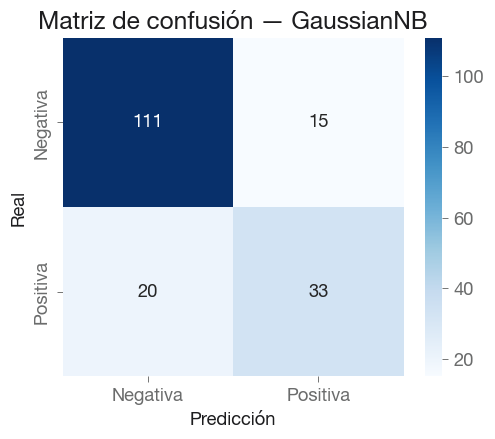

------------------------------------------------------------------------------------------------------------------------


In [190]:
gnb = GaussianNB()
gnb.fit(X_train_vec.toarray(), y_train)

acc_gnb = evaluate_model(gnb, X_test_vec.toarray(), y_test, "GaussianNB")

### MultinomialNB:

+-----------------------+
| Modelo: MultinomialNB |
+-----------------------+
Accuracy: 0.8156

Classification report:
              precision    recall  f1-score   support

    Negativa       0.84      0.90      0.87       126
    Positiva       0.73      0.60      0.66        53

    accuracy                           0.82       179
   macro avg       0.79      0.75      0.77       179
weighted avg       0.81      0.82      0.81       179



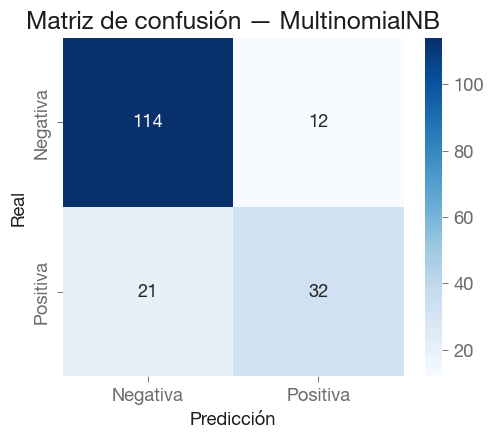

------------------------------------------------------------------------------------------------------------------------


In [191]:
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)

acc_mnb = evaluate_model(mnb, X_test_vec, y_test, "MultinomialNB")

### BernoulliNB:

+---------------------+
| Modelo: BernoulliNB |
+---------------------+
Accuracy: 0.7709

Classification report:
              precision    recall  f1-score   support

    Negativa       0.79      0.93      0.85       126
    Positiva       0.70      0.40      0.51        53

    accuracy                           0.77       179
   macro avg       0.74      0.66      0.68       179
weighted avg       0.76      0.77      0.75       179



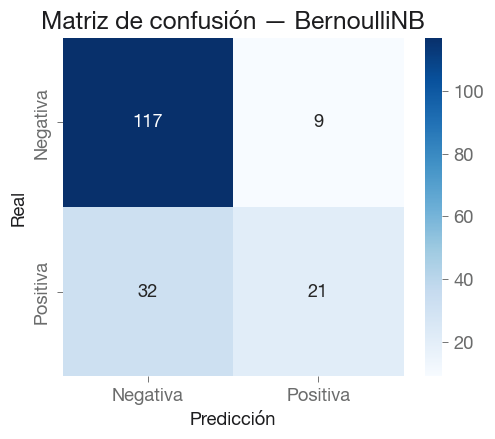

------------------------------------------------------------------------------------------------------------------------


In [192]:
bnb = BernoulliNB()
bnb.fit(X_train_vec, y_train)

acc_bnb = evaluate_model(bnb, X_test_vec, y_test, "BernoulliNB")

## Paso 4: Optimiza el modelo

El enunciado menciona `RandomForest`. Lo pruebo como experimento y luego hago la optimización real con `GridSearchCV` sobre el parámetro `alpha` de `MultinomialNB`.

+----------------------+
| Modelo: RandomForest |
+----------------------+
Accuracy: 0.7989

Classification report:
              precision    recall  f1-score   support

    Negativa       0.88      0.83      0.85       126
    Positiva       0.64      0.74      0.68        53

    accuracy                           0.80       179
   macro avg       0.76      0.78      0.77       179
weighted avg       0.81      0.80      0.80       179



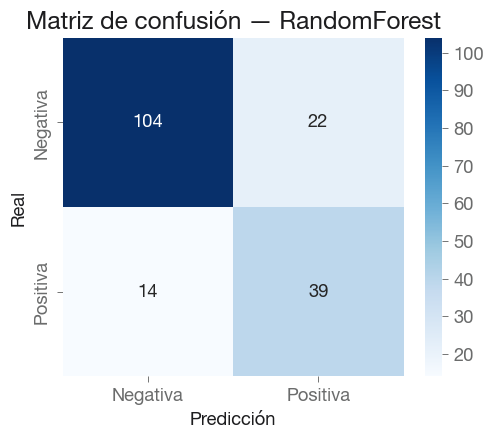

------------------------------------------------------------------------------------------------------------------------


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_vec.toarray(), y_train)

acc_rf = evaluate_model(rf, X_test_vec.toarray(), y_test, "RandomForest")

### Optimización real con GridSearchCV

Como `RandomForest` no mejora los resultados, la optimización real la hago con `GridSearchCV` probando diferentes valores de `alpha` para `MultinomialNB`.


Mejor alpha: 0.5
Mejor CV accuracy (train): 0.8146

+------------------------------------+
| Modelo: MultinomialNB (optimizado) |
+------------------------------------+
Accuracy: 0.8268

Classification report:
              precision    recall  f1-score   support

    Negativa       0.86      0.90      0.88       126
    Positiva       0.73      0.66      0.69        53

    accuracy                           0.83       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.82      0.83      0.82       179



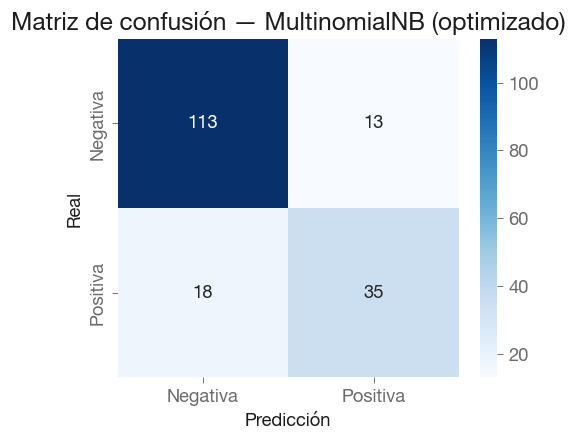

------------------------------------------------------------------------------------------------------------------------


In [200]:
param_grid = {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}

grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

grid.fit(X_train_vec, y_train)

print(f"Mejor alpha: {grid.best_params_['alpha']}")
print(f"Mejor CV accuracy (train): {grid.best_score_:.4f}\n")

best_mnb = grid.best_estimator_
acc_best = evaluate_model(best_mnb, X_test_vec, y_test, "MultinomialNB (optimizado)")

## Paso 5: Guarda el modelo

In [203]:
joblib.dump(best_mnb, "../models/multinomial_nb_optimized.pkl")
joblib.dump(vectorizer, "../models/multinomial_nb_vectorizer.pkl")

print("Modelos guardados en ../models/")

Modelos guardados en ../models/


## Paso 6: Explora otras alternativas

Voy a elegir `Regresión logística` para explorar alternativas.

+----------------------------+
| Modelo: LogisticRegression |
+----------------------------+
Accuracy: 0.8324

Classification report:
              precision    recall  f1-score   support

    Negativa       0.91      0.84      0.88       126
    Positiva       0.68      0.81      0.74        53

    accuracy                           0.83       179
   macro avg       0.80      0.83      0.81       179
weighted avg       0.85      0.83      0.84       179



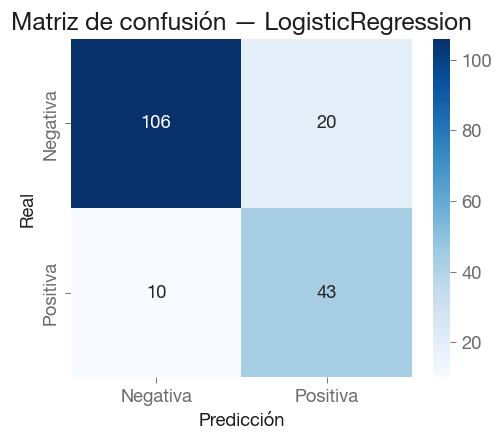

------------------------------------------------------------------------------------------------------------------------


In [202]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

acc_lr = evaluate_model(lr, X_test_vec, y_test, "LogisticRegression")

## Comparación

In [196]:
results = pd.DataFrame({
    "Modelo": [
        "LogisticRegression",
        "MultinomialNB (optimizado)",
        "MultinomialNB",
        "GaussianNB",
        "BernoulliNB"
    ],
    "Accuracy": [acc_lr, acc_best, acc_mnb, acc_gnb, acc_bnb]
})

results = results.sort_values("Accuracy", ascending=False)
display(results)

,Modelo,Accuracy
0,LogisticRegression,0.832402
1,MultinomialNB (optimizado),0.826816
2,MultinomialNB,0.815642
3,GaussianNB,0.804469
4,BernoulliNB,0.770950


# Conclusiones finales

El `mejor modelo` de `Naive Bayes` ha sido `MultinomialNB` con `alpha=0.5` (accuracy 0.8268).
`LogisticRegression` ha superado a todos los `Naive Bayes` (accuracy 0.8324) y ha tenido mejor `recall` en la clase positiva (0.81 vs 0.66).
El dataset está desbalanceado (65% negativas) por lo que `accuracy` sola no es suficiente. Hay que mirar `recall` de la clase minoritaria.

He guardado el modelo optimizado de `Naive Bayes` con `MultinomialNB`.